In [1]:
import pandas as pd
df_case = pd.read_csv('dataset case newyork_sanfrancisco.csv')

In [2]:
df_case.head()

,in_sf,beds,bath,price,year_built,sqft,price_per_sqft,elevation
0,0,2.0,1.0,999000,1960,1000,999,10
1,0,2.0,2.0,2750000,2006,1418,1939,0
2,0,2.0,2.0,1350000,1900,2150,628,9
3,0,1.0,1.0,629000,1903,500,1258,9
4,0,0.0,1.0,439000,1930,500,878,10


In [3]:
df_case.sample(10)

,in_sf,beds,bath,price,year_built,sqft,price_per_sqft,elevation
354,1,3.0,2.0,848000,1940,1500,565,42
6,0,1.0,1.0,475000,1920,500,950,10
120,0,5.0,5.0,19000000,2016,4972,3821,10
337,1,1.0,1.0,650000,1955,600,1083,74
1,0,2.0,2.0,2750000,2006,1418,1939,0
485,1,4.0,4.0,3760000,1894,3085,1219,49
104,0,0.0,1.0,449000,1962,550,816,10
328,1,2.0,1.0,500000,1958,1166,429,136
7,0,1.0,1.0,975000,1930,900,1083,10
340,1,1.0,1.0,825000,1955,600,1375,74


In [4]:
df_case.shape

(492, 8)

<Axes: xlabel='price_per_sqft', ylabel='elevation'>

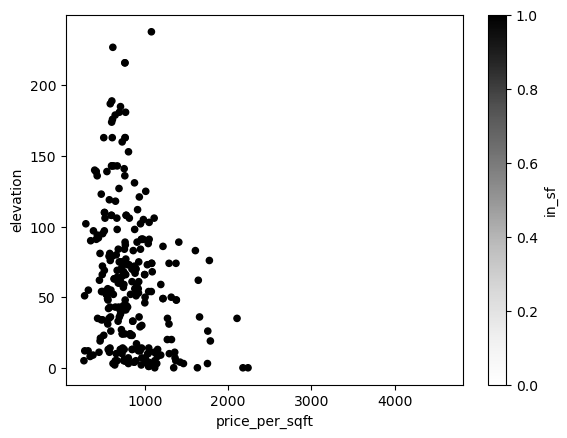

In [5]:
df_case.plot.scatter(x='price_per_sqft',
                      y='elevation',
                      c='in_sf')

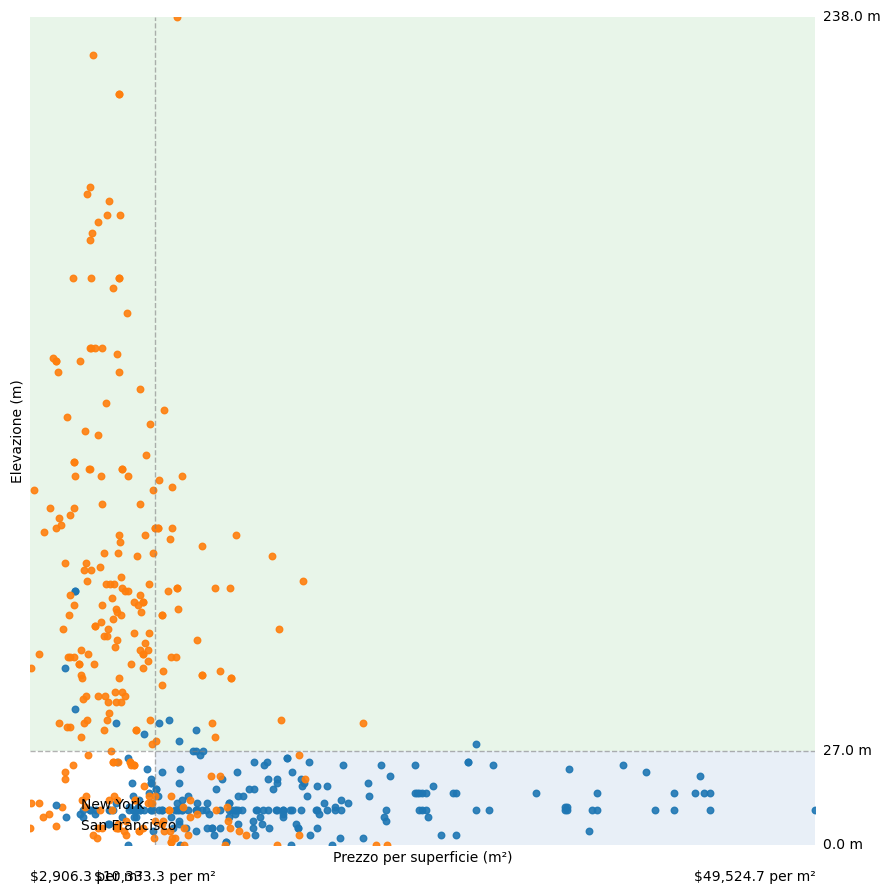

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

df = pd.read_csv("case newyork_sanfrancisco.csv")

# Conversione: 1 m² = 10.7639 ft²
df["price_per_m2"] = df["price_per_sqft"] * 10.7639

sf = df[df["in_sf"] == 1]
ny = df[df["in_sf"] == 0]

x = "price_per_m2"
y = "elevation"

# Soglie (puoi fissarle per avere numeri “belli” come nel mock)
x_split = df[x].median()
y_split = df[y].quantile(0.6)

xmin, xmax = df[x].min(), df[x].max()
ymin, ymax = df[y].min(), df[y].max()

fig, ax = plt.subplots(figsize=(9, 9))

# Aree evidenziate
ax.add_patch(Rectangle((xmin, y_split), xmax - xmin, ymax - y_split,
                       facecolor="#e8f5e9", edgecolor="none", zorder=0))
ax.add_patch(Rectangle((x_split, ymin), xmax - x_split, y_split - ymin,
                       facecolor="#e8eff7", edgecolor="none", zorder=0))

# Punti
ax.scatter(ny[x], ny[y], s=22, alpha=0.9, label="New York", zorder=2)
ax.scatter(sf[x], sf[y], s=22, alpha=0.9, label="San Francisco", zorder=2)

# Linee di split
ax.axvline(x_split, linestyle="--", linewidth=1, color="grey", alpha=0.6)
ax.axhline(y_split, linestyle="--", linewidth=1, color="grey", alpha=0.6)

# Annotazioni stile “bordo”
ax.text(xmin, ymin - (ymax - ymin)*0.03, f"${xmin:,.1f} per m²", ha="left", va="top")
ax.text(x_split, ymin - (ymax - ymin)*0.03, f"${x_split:,.1f} per m²", ha="center", va="top")
ax.text(xmax, ymin - (ymax - ymin)*0.03, f"${xmax:,.1f} per m²", ha="right", va="top")

ax.text(xmax + (xmax - xmin)*0.01, ymin,  f"{ymin:.1f} m", ha="left", va="center")
ax.text(xmax + (xmax - xmin)*0.01, y_split, f"{y_split:.1f} m", ha="left", va="center")
ax.text(xmax + (xmax - xmin)*0.01, ymax,  f"{ymax:.1f} m", ha="left", va="center")

# Look pulito
ax.set_xlabel("Prezzo per superficie (m²)")
ax.set_ylabel("Elevazione (m)")
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.legend(loc="lower left", frameon=False)
plt.tight_layout()
plt.show()


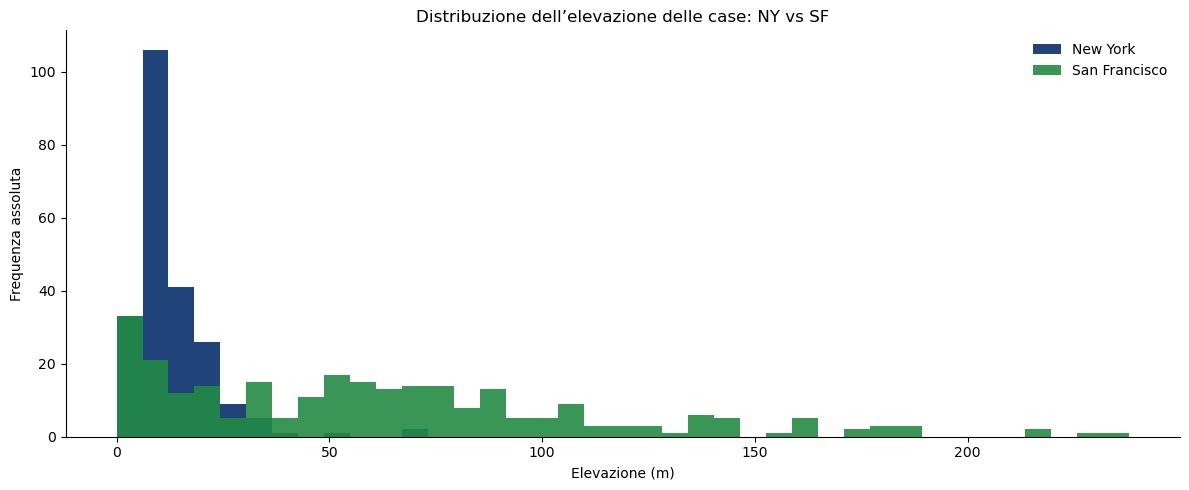

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === 1) Caricamento dataset ===
df = pd.read_csv("case newyork_sanfrancisco.csv")

# separiamo le due città
sf = df[df["in_sf"] == 1]["elevation"]
ny = df[df["in_sf"] == 0]["elevation"]

# === 2) Definizione dei bin (stessi per entrambe le città) ===
bins = np.linspace(df["elevation"].min(), df["elevation"].max(), 40)

# === 3) Creazione figure ===
fig, ax = plt.subplots(figsize=(12, 5))

# istogrammi con alpha per leggero overlap visivo
ax.hist(ny, bins=bins, color="#08306b", alpha=0.9, label="New York")
ax.hist(sf, bins=bins, color="#238b45", alpha=0.9, label="San Francisco")

# === 4) Styling ===
ax.set_xlabel("Elevazione (m)")
ax.set_ylabel("Frequenza assoluta")
ax.set_title("Distribuzione dell’elevazione delle case: NY vs SF")

ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


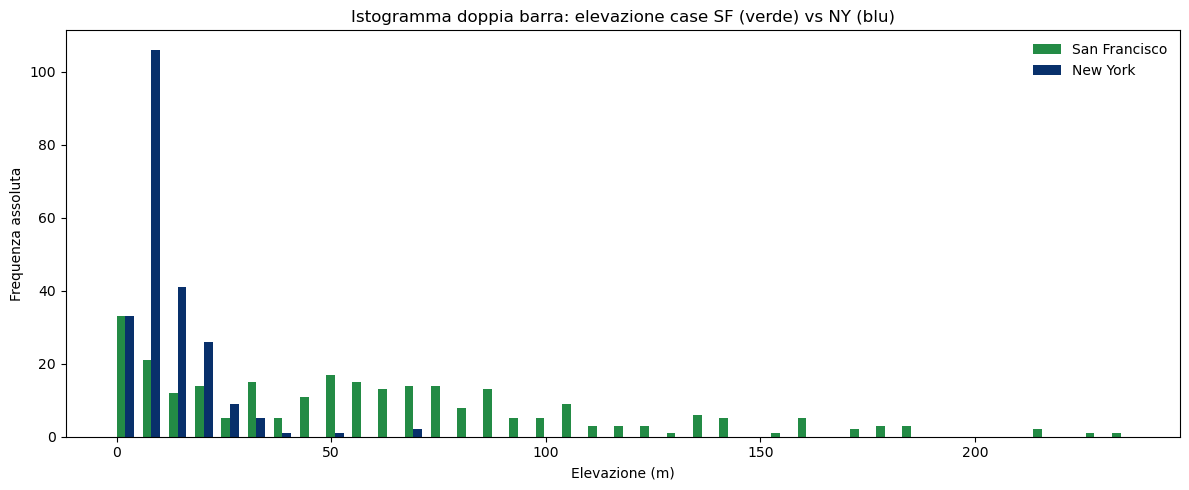

In [10]:
# Calcolo delle frequenze per i due gruppi
import numpy as np
counts_sf, bins_sf = np.histogram(sf, bins=bins)
counts_ny, bins_ny = np.histogram(ny, bins=bins)

width = (bins_sf[1] - bins_sf[0]) / 3

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(bins_sf[:-1], counts_sf, width=width, color="#238b45", label="San Francisco", align="edge")
ax.bar(bins_ny[:-1] + width, counts_ny, width=width, color="#08306b", label="New York", align="edge")

ax.set_xlabel("Elevazione (m)")
ax.set_ylabel("Frequenza assoluta")
ax.set_title("Istogramma doppia barra: elevazione case SF (verde) vs NY (blu)")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()
